# 🎯 PCA (Temel Bileşen Analizi) - Sıfırdan Açıklamalı Eğitim

---

## 📋 Demo Bilgileri

**Hazırlayan:** Çağatay ÜRESİN  
**Öğrenci No:** 20259257001  
**Kurum:** Sivas Cumhuriyet Üniversitesi  
**Enstitü:** Fen Bilimleri Enstitüsü  
**Anabilim Dalı:** Bilgisayar Mühendisliği  
**Ders:** Makine Öğrenmesi  
**Ders Hocası:** Prof. Dr. Hidayet TAKCI

**Kaynak Makale:**  
*"A Tutorial on Principal Component Analysis"*  
Jonathon Shlens, 2005

**İletişim:**
- 📧 Email: cagatayuresin@gmail.com
- 🔗 GitHub: [cagatayuresin](https://github.com/cagatayuresin)
- 💼 LinkedIn: [cagatayuresin](https://linkedin.com/in/cagatayuresin)

---

## 📚 Bu Notebook'ta Ne Öğreneceğiz?

Bu interaktif notebook'ta **yüksek boyutlu veriyi daha basit hale getirmeyi** öğreneceğiz. Günlük hayattan bir örnekle başlayalım:

### 🏠 Günlük Hayattan Örnek: Ev Fiyatları

Bir evin fiyatını tahmin etmek istediğinizi düşünün. Elinizde şu bilgiler var:
- 📏 Oda sayısı
- 📐 Metrekare
- 🚗 Otopark sayısı
- 🏊 Havuz var mı?
- 🏙️ Şehir merkezi uzaklığı
- ... ve 100 tane daha özellik!

**Problem:** Bu 100 özelliğin hepsine ihtiyacımız var mı? Belki bazıları birbiriyle ilişkili?

**Çözüm:** PCA ile bu 100 özelliği 5-10 "ana özellik"e indirgeyebiliriz!

---

## 🤔 Temel Kavramlar - Basit Anlatım

### 1️⃣ Varyans Nedir?

**Basit Anlatım:** Varyans, verilerinizin ne kadar "dağınık" olduğunu gösterir.

**Örnek:**
- Sınıftaki öğrencilerin boyları: 170, 171, 169, 172, 170 cm → **Düşük varyans** (herkes birbirine yakın)
- Başka bir sınıf: 150, 190, 165, 175, 185 cm → **Yüksek varyans** (büyük farklar var)

**Formül:**
$$\text{Varyans} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

Yani: Her değerin ortalamadan ne kadar uzak olduğunu ölçüyoruz.

---

### 2️⃣ Kovaryans Nedir?

**Basit Anlatım:** Kovaryans, iki özelliğin **birlikte nasıl değiştiğini** gösterir.

**Örnek:**
- Boy ve kilo: Boy arttıkça kilo da artıyor → **Pozitif kovaryans**
- Çalışma saati ve başarısızlık: Çalışma arttıkça başarısızlık azalıyor → **Negatif kovaryans**
- Boy ve saç rengi: İlişki yok → **Sıfıra yakın kovaryans**

**Formül:**
$$\text{Cov}(X,Y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

---

### 3️⃣ PCA Nedir?

**Basit Anlatım:** PCA, karmaşık veriyi **en önemli yönlere** odaklanarak basitleştirir.

**Gerçek Dünya Analojisi:**
Bir kutuyu fotoğraflamak istiyorsunuz:
- 📸 Önden çekersen kutu çok iyi görünür (en önemli açı)
- 📸 Yandan çekersen de bilgi alırsın ama daha az
- 📸 Üstten çekersen neredeyse hiçbir şey görmezsin (gereksiz açı)

**PCA da bunu yapar:** Veriyi en iyi açıklayan "açıları" (temel bileşenleri) bulur!

---

### 4️⃣ Boyut İndirgeme Neden Önemli?

✅ **Hız:** Daha az veri → Daha hızlı hesaplama  
✅ **Görselleştirme:** 1000 boyutlu veriyi 2D/3D'de gösterebiliriz  
✅ **Gürültü azaltma:** Önemsiz detayları atarız  
✅ **Depolama:** Daha az yer kaplar  
✅ **Overfitting önleme:** Model daha sağlıklı öğrenir

---

## 🎬 Bu Notebook'un Akışı

1. **Veri Yükleme:** MNIST rakam görüntüleri (28×28 = 784 piksel)
2. **Keşif:** Veriye bakalım, kovaryans matrisini görelim
3. **PCA Uygulama:** 784 boyutu → 50-100 boyuta indirelim
4. **Görselleştirme:** 2D ve 3D'de veriyi görelim
5. **İnteraktif Demo:** Farklı ayarlarla deneyim kazanalım

---

## 🎯 Beklenen Sonuçlar

Bu notebook sonunda:
- ✅ 784 boyutlu MNIST verisini %95 doğrulukla ~150 boyuta indirgeceğiz
- ✅ Görüntüleri 2-3 bileşenle bile tanınabilir hale getireceğiz
- ✅ Hangi "yönlerin" (temel bileşenlerin) önemli olduğunu göreceğiz

**Hadi başlayalım! 🚀**

---

In [1]:
## 1️⃣ KURULUM - Gerekli Kütüphaneleri Yükleyelim

# Not: Bu hücreyi sadece bir kez çalıştırın
# Eğer zaten yüklüyse atlanabilir

%pip install -q numpy matplotlib scikit-learn seaborn ipywidgets

print("\n" + "="*60)
print("✅ Tüm paketler başarıyla kuruldu!")
print("="*60)
print("\n💡 Şimdi sonraki hücreleri çalıştırabilirsiniz.")
print("\n📦 Yüklenen kütüphaneler:")
print("  • numpy: Matematiksel hesaplamalar")
print("  • matplotlib: Grafikler")
print("  • scikit-learn: PCA algoritması")
print("  • seaborn: Güzel grafikler")
print("  • ipywidgets: Interaktif kontroller")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.0 MB/s eta 0:00:00

✅ Tüm paketler başarıyla kuruldu!

💡 Şimdi sonraki hücreleri çalıştırabilirsiniz.

📦 Yüklenen kütüphaneler:
  • numpy: Matematiksel hesaplamalar
  • matplotlib: Grafikler
  • scikit-learn: PCA algoritması
  • seaborn: Güzel grafikler
  • ipywidgets: Interaktif kontroller


## 2️⃣ MNIST Veri Setini Yükleme

**MNIST** (Modified National Institute of Standards and Technology) veri seti:
- 70,000 el yazısı rakam görüntüsü
- Her görüntü: 28×28 = **784 piksel**
- Sınıflar: 0-9 arası rakamlar

In [2]:
%%time
# Gerekli kütüphaneleri import et
from sklearn.datasets import fetch_openml
import numpy as np

# MNIST veri setini yükle
print("🔄 MNIST veri seti yükleniyor... (İlk çalıştırmada zaman alabilir)")
print("\n💡 MNIST NEDİR?")
print("   • 70,000 el yazısı rakam görüntüsü (0-9)")
print("   • Her görüntü 28×28 piksel = 784 özellik")
print("   • Yani her görüntü 784 boyutlu bir vektör!")
print("   • Makine öğrenmesinde en popüler test veri seti\n")

mnist = fetch_openml('mnist_784', version=1, parser='auto')
X_full, y_full = mnist.data, mnist.target

# İlk 3000 örneği alalım (hız için)
n_samples = 3000
X = np.array(X_full[:n_samples])
y = np.array(y_full[:n_samples], dtype=int)

print(f"\n✅ Veri yüklendi!")
print(f"{'='*60}")
print(f"📊 Veri Seti Bilgileri:")
print(f"{'='*60}")
print(f"  • Örnek sayısı: {X.shape[0]:,}")
print(f"  • Her görüntü: {X.shape[1]} piksel (28×28)")
print(f"  • Veri boyutu: {X.shape}")
print(f"  • Veri tipi: {X.dtype}")
print(f"  • Piksel değer aralığı: [{X.min():.1f}, {X.max():.1f}]")
print(f"  • Sınıf dağılımı:")
unique, counts = np.unique(y, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"    Rakam {digit}: {count:3d} örnek")
print(f"{'='*60}")
print(f"\n🎯 BOYUT SORUNU:")
print(f"   784 boyut çok fazla! PCA ile bunu ~50-150'ye indireceğiz.")

🔄 MNIST veri seti yükleniyor... (İlk çalıştırmada zaman alabilir)

💡 MNIST NEDİR?
   • 70,000 el yazısı rakam görüntüsü (0-9)
   • Her görüntü 28×28 piksel = 784 özellik
   • Yani her görüntü 784 boyutlu bir vektör!
   • Makine öğrenmesinde en popüler test veri seti


✅ Veri yüklendi!
📊 Veri Seti Bilgileri:
  • Örnek sayısı: 3,000
  • Her görüntü: 784 piksel (28×28)
  • Veri boyutu: (3000, 784)
  • Veri tipi: int64
  • Piksel değer aralığı: [0.0, 255.0]
  • Sınıf dağılımı:
    Rakam 0: 285 örnek
    Rakam 1: 339 örnek
    Rakam 2: 299 örnek
    Rakam 3: 295 örnek
    Rakam 4: 325 örnek
    Rakam 5: 274 örnek
    Rakam 6: 306 örnek
    Rakam 7: 329 örnek
    Rakam 8: 261 örnek
    Rakam 9: 287 örnek

🎯 BOYUT SORUNU:
   784 boyut çok fazla! PCA ile bunu ~50-150'ye indireceğiz.
CPU times: user 9.21 s, sys: 1.28 s, total: 10.5 s
Wall time: 22.3 s


## 3️⃣ Orijinal Veriyi Görselleştirme

### 3.1 - Örnek Görüntüler

### 🎯 Ne Göreceğiz?

Aşağıdaki görselleştirmede:
1. **30 farklı el yazısı rakam** göreceğiz
2. Her görüntü **28×28 = 784 piksel**
3. Bu kadar çok boyutu nasıl azaltabileceğimizi öğreneceğiz

**Dikkat edin:** Her görüntü aslında 784 sayı! (Her piksel bir özellik)

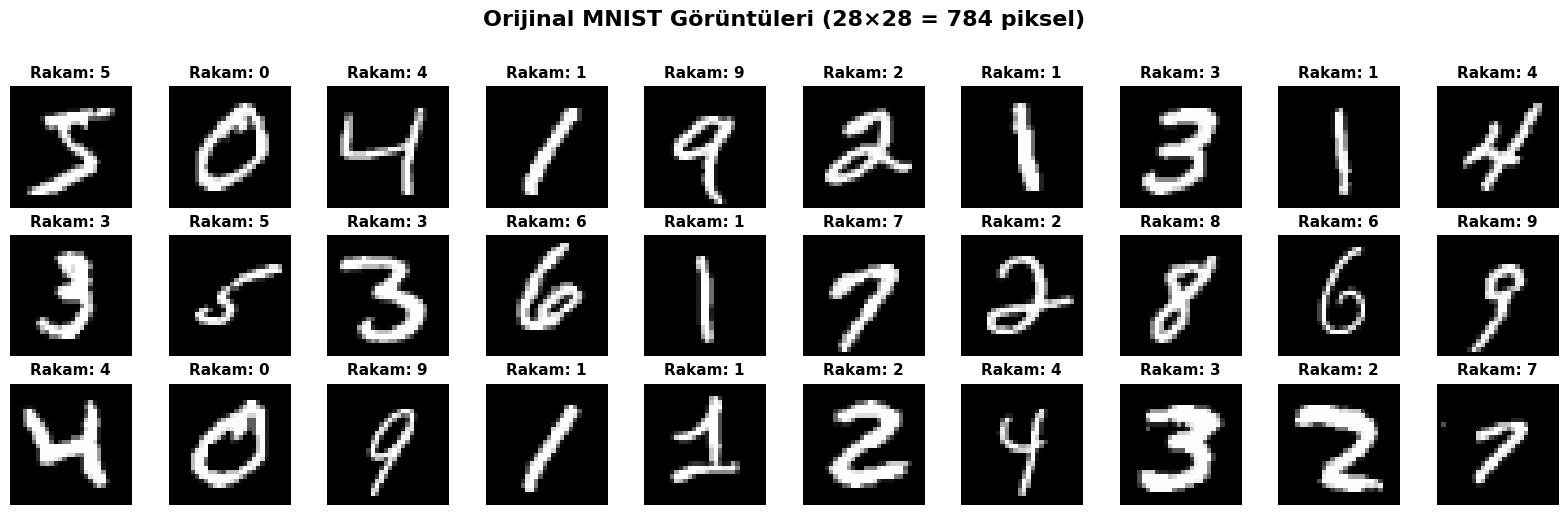

✅ İlk 30 görüntü gösterildi


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
fig.suptitle('Orijinal MNIST Görüntüleri (28×28 = 784 piksel)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, ax in enumerate(axes.flat):
    image = X[idx].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Rakam: {y[idx]}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ İlk 30 görüntü gösterildi")

### 3.2 - Kovaryans Matrisi

Kovaryans matrisi, pikseller arasındaki ilişkileri gösterir.

### 💡 Kovaryans ve Korelasyon - Ne Farkı Var?

**Kovaryans:** İki değişkenin birlikte nasıl değiştiğini gösterir (birim vardır)  
**Korelasyon:** Kovaryansın standartlaştırılmış hali (-1 ile +1 arası)

**Korelasyon değerleri:**
- **+1:** Mükemmel pozitif ilişki (biri artarsa diğeri de artar)
- **0:** İlişki yok
- **-1:** Mükemmel negatif ilişki (biri artarsa diğeri azalır)

**Neden önemli?** PCA, yüksek kovaryansa sahip pikselleri bulup onları birleştirir!

🔄 Kovaryans ve korelasyon matrisleri hesaplanıyor...

📊 Kovaryans matrisi boyutu: 784 x 784
📉 Filtreleme: 784 piksel → 579 değişken piksel
   (Sabit 205 piksel çıkarıldı)

📊 KORELASYON İSTATİSTİKLERİ:
   • Ortalama korelasyon: 0.087
   • Maksimum korelasyon: 1.000
   • Yüksek korelasyon (>0.7): 1,024 çift piksel


/tmp/ipython-input-3537446472.py:103: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


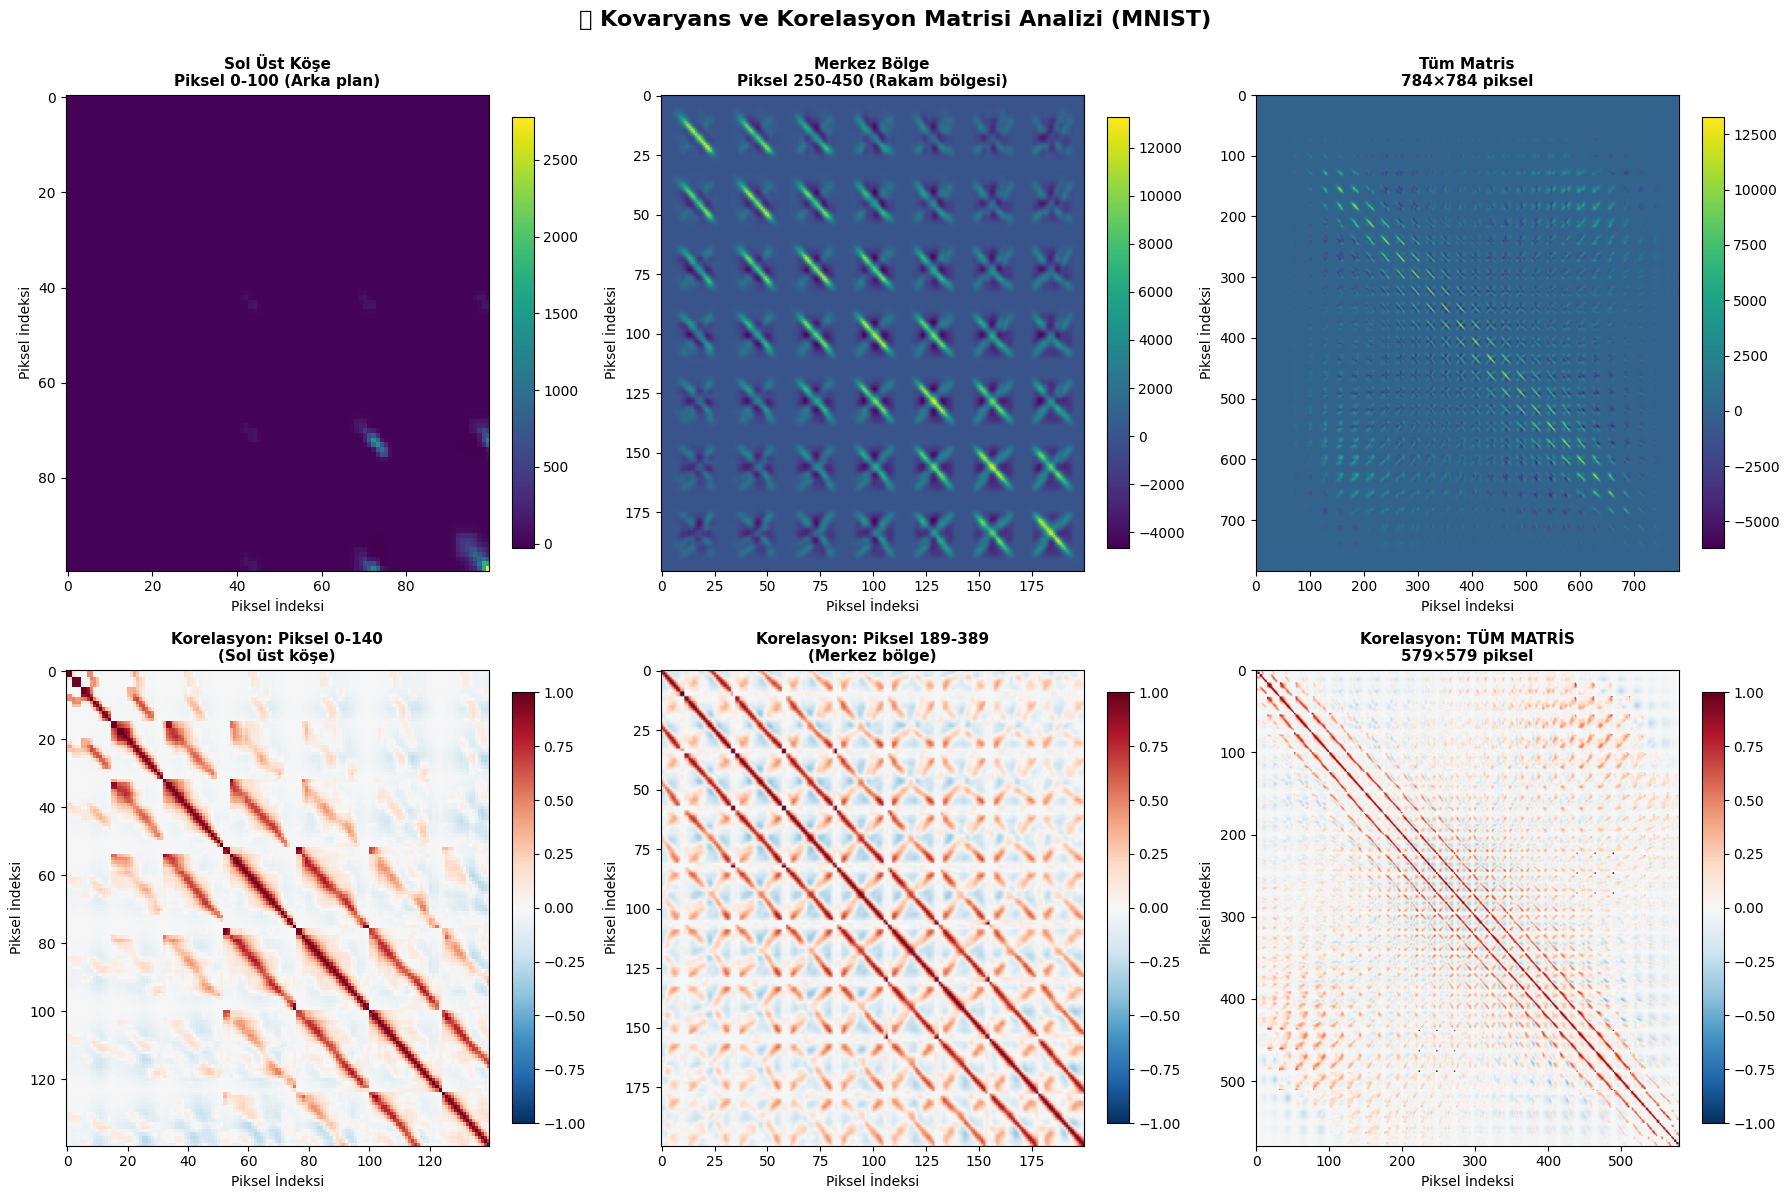


💡 NE GÖRMELIYIZ? (Normal Durum)
✅ KOVARYANS MATRİSİ:
   • Diyagonal parlak (her piksel kendisiyle yüksek kovaryans)
   • Merkez bölge daha parlak (rakamların olduğu pikseller)
   • Köşeler koyu (arka plan, çok az değişim)
   • Blok yapılar: Komşu pikseller birlikte değişiyor

✅ KORELASYON MATRİSİ:
   • Diyagonal kırmızı (+1: mükemmel pozitif korelasyon)
   • Yakın pikseller arası kırmızı-turuncu (yüksek korelasyon)
   • Uzak pikseller beyaz-mavi (düşük/negatif korelasyon)
   • Blok/bant desenleri: 28×28 grid yapısının yansıması

🎯 PCA'NIN YAPTIĞI:
   • Yüksek korelasyonlu pikselleri birleştirmek
   • Örnek: Komşu 10 piksel → 1 temel bileşen
   • Sonuç: 784 piksel → ~150 bileşen (%95 bilgi)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

print("🔄 Kovaryans ve korelasyon matrisleri hesaplanıyor...\n")

# Daha büyük bir örnek alalım (daha güvenilir istatistikler için)
X_sample = X[:500]

# Tam kovaryans matrisini hesapla (784x784)
print("📊 Kovaryans matrisi boyutu:", X_sample.shape[1], "x", X_sample.shape[1])
cov_matrix = np.cov(X_sample.T)

# Görselleştirme için 3 farklı bölgeyi gösterelim
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🔍 Kovaryans ve Korelasyon Matrisi Analizi (MNIST)',
             fontsize=16, fontweight='bold', y=0.995)

# === ÜST SATIR: KOVARYANS MATRİSİ ===

# Sol üst köşe (ilk 100 piksel) - genelde arka plan
ax1 = axes[0, 0]
im1 = ax1.imshow(cov_matrix[:100, :100], cmap='viridis', aspect='auto')
ax1.set_title('Sol Üst Köşe\nPiksel 0-100 (Arka plan)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Piksel İndeksi')
ax1.set_ylabel('Piksel İndeksi')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Merkez bölge (250-450 pikseller) - rakamların olduğu bölge
ax2 = axes[0, 1]
im2 = ax2.imshow(cov_matrix[250:450, 250:450], cmap='viridis', aspect='auto')
ax2.set_title('Merkez Bölge\nPiksel 250-450 (Rakam bölgesi)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Piksel İndeksi')
ax2.set_ylabel('Piksel İndeksi')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Tam matris küçültülmüş
ax3 = axes[0, 2]
im3 = ax3.imshow(cov_matrix, cmap='viridis', aspect='auto')
ax3.set_title('Tüm Matris\n784×784 piksel', fontsize=11, fontweight='bold')
ax3.set_xlabel('Piksel İndeksi')
ax3.set_ylabel('Piksel İndeksi')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# === ALT SATIR: KORELASYON MATRİSİ ===

# Varyansı sıfır olan pikselleri filtrele
std_devs = np.std(X_sample, axis=0)
non_constant_mask = std_devs > 1e-6  # Çok küçük varyansları da filtrele
X_filtered = X_sample[:, non_constant_mask]

print(f"📉 Filtreleme: 784 piksel → {X_filtered.shape[1]} değişken piksel")
print(f"   (Sabit {784 - X_filtered.shape[1]} piksel çıkarıldı)\n")

if X_filtered.shape[1] > 1:
    corr_matrix = np.corrcoef(X_filtered.T)
    total_pixels = corr_matrix.shape[0]

    # Sol: İlk bölge (0-140 piksel arası)
    ax4 = axes[1, 0]
    im4 = ax4.imshow(corr_matrix[:140, :140],
                     cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax4.set_title(f'Korelasyon: Piksel 0-140\n(Sol üst köşe)', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Piksel İndeksi')
    ax4.set_ylabel('Piksel İndeksi')
    plt.colorbar(im4, ax=ax4, fraction=0.046)

    # Orta: Merkez bölge (rakamların olduğu alan)
    mid_start = max(0, total_pixels//2 - 100)
    mid_end = min(total_pixels, mid_start + 200)
    ax5 = axes[1, 1]
    im5 = ax5.imshow(corr_matrix[mid_start:mid_end, mid_start:mid_end],
                     cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax5.set_title(f'Korelasyon: Piksel {mid_start}-{mid_end}\n(Merkez bölge)',
                  fontsize=11, fontweight='bold')
    ax5.set_xlabel('Piksel İndeksi')
    ax5.set_ylabel('Piksel İndeksi')
    plt.colorbar(im5, ax=ax5, fraction=0.046)

    # Sağ: TÜM MATRİS (tüm pikseller)
    ax6 = axes[1, 2]
    im6 = ax6.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax6.set_title(f'Korelasyon: TÜM MATRİS\n{total_pixels}×{total_pixels} piksel',
                  fontsize=11, fontweight='bold')
    ax6.set_xlabel('Piksel İndeksi')
    ax6.set_ylabel('Piksel İndeksi')
    plt.colorbar(im6, ax=ax6, fraction=0.046)

    # İstatistikler
    high_corr = np.sum(np.abs(corr_matrix) > 0.7) - corr_matrix.shape[0]
    high_corr = high_corr // 2  # Simetrik matris, çift saymayalım

    print("📊 KORELASYON İSTATİSTİKLERİ:")
    print(f"   • Ortalama korelasyon: {np.mean(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])):.3f}")
    print(f"   • Maksimum korelasyon: {np.max(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]):.3f}")
    print(f"   • Yüksek korelasyon (>0.7): {high_corr:,} çift piksel")

else:
    for ax in [axes[1, 0], axes[1, 1], axes[1, 2]]:
        ax.text(0.5, 0.5, 'Yetersiz değişken piksel',
                ha='center', va='center', fontsize=12, color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 NE GÖRMELIYIZ? (Normal Durum)")
print("="*70)
print("✅ KOVARYANS MATRİSİ:")
print("   • Diyagonal parlak (her piksel kendisiyle yüksek kovaryans)")
print("   • Merkez bölge daha parlak (rakamların olduğu pikseller)")
print("   • Köşeler koyu (arka plan, çok az değişim)")
print("   • Blok yapılar: Komşu pikseller birlikte değişiyor")
print("\n✅ KORELASYON MATRİSİ:")
print("   • Diyagonal kırmızı (+1: mükemmel pozitif korelasyon)")
print("   • Yakın pikseller arası kırmızı-turuncu (yüksek korelasyon)")
print("   • Uzak pikseller beyaz-mavi (düşük/negatif korelasyon)")
print("   • Blok/bant desenleri: 28×28 grid yapısının yansıması")
print("\n🎯 PCA'NIN YAPTIĞI:")
print("   • Yüksek korelasyonlu pikselleri birleştirmek")
print("   • Örnek: Komşu 10 piksel → 1 temel bileşen")
print("   • Sonuç: 784 piksel → ~150 bileşen (%95 bilgi)")
print("="*70)

## 4️⃣ PCA Analizi - Matematiksel Hesaplamalar

### 4.1 - Veri Standartlaştırma

PCA'dan önce veriyi standartlaştırıyoruz: $X_{scaled} = \frac{X - \mu}{\sigma}$

### 🎓 Standartlaştırma Neden Gerekli?

PCA'dan önce veriyi standartlaştırıyoruz çünkü:

**Problem:** Farklı özelliklerin farklı ölçekleri olabilir
- Örnek 1: Gelir (50,000 TL) vs Yaş (30 yıl)
- Gelir çok büyük olduğu için PCA'yı domine eder!

**Çözüm:** Her özelliği ortalaması 0, standart sapması 1 olacak şekilde dönüştürürüz:

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

**Sonuç:** Artık tüm özellikler eşit öneme sahip!

In [5]:
%%time
from sklearn.preprocessing import StandardScaler

print("🔄 Veri standartlaştırılıyor...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Standartlaştırma tamamlandı!")
print(f"\n📊 Standartlaştırılmış Veri İstatistikleri:")
print(f"  • Ortalama: {X_scaled.mean():.6f} (≈ 0)")
print(f"  • Standart sapma: {X_scaled.std():.6f} (≈ 1)")
print(f"  • Min değer: {X_scaled.min():.2f}")
print(f"  • Max değer: {X_scaled.max():.2f}")

🔄 Veri standartlaştırılıyor...
✅ Standartlaştırma tamamlandı!

📊 Standartlaştırılmış Veri İstatistikleri:
  • Ortalama: -0.000000 (≈ 0)
  • Standart sapma: 0.910539 (≈ 1)
  • Min değer: -1.31
  • Max değer: 54.76
CPU times: user 67.1 ms, sys: 1.02 ms, total: 68.1 ms
Wall time: 165 ms


### 4.2 - PCA Hesaplama

Tüm temel bileşenleri hesaplıyoruz.

### 🔍 PCA Nasıl Çalışır? - Adım Adım

**Amaç:** 784 boyutlu veriyi daha az boyuta indirgemek ama bilgiyi korumak

**PCA'nın Yaptığı İşlem (Basitçe):**

1. **Adım 1:** Veriyi standartlaştır (yukarıda yaptık)
2. **Adım 2:** Kovaryans matrisini hesapla (hangi pikseller birlikte değişiyor?)
3. **Adım 3:** En önemli "yönleri" bul (eigenvalue/eigenvector)
4. **Adım 4:** Veriyi bu yönlere "döndür" (projeksiyon)
5. **Adım 5:** En önemli yönleri tut, gerisini at!

**Gerçek Dünya Analojisi:**
Bir grup insanı yukarıdan çeken fotoğraf → Sadece boylar görünür (1 boyut)  
Önden çeken fotoğraf → Boy + vücut genişliği görünür (2 boyut)  
**PCA:** En bilgi veren açıları otomatik bulur!

**Matematiksel olarak:** PCA, varyansı maksimize eden ortogonal (dik) yönleri bulur.

In [6]:
%%time
from sklearn.decomposition import PCA

print("🔄 PCA hesaplanıyor... (Bu birkaç saniye sürebilir)")

# Tüm bileşenleri hesapla
pca_full = PCA()
pca_full.fit(X_scaled)

# Sonuçları kaydet
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# %95 varyans için kaç bileşen gerekli?
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\n✅ PCA hesaplama tamamlandı!")
print(f"\n{'='*70}")
print(f"🎯 PCA SONUÇLARI:")
print(f"{'='*70}")
print(f"\n📊 İlk 10 Temel Bileşenin Katkısı:")
for i in range(10):
    print(f"  PC{i+1:2d}: %{explained_variance[i]*100:5.2f}  "
          f"(Kümülatif: %{cumulative_variance[i]*100:5.2f})")

print(f"\n🎯 Bileşen Sayısı Gereksinimleri:")
print(f"  • %90 varyans için: {n_components_90:3d} bileşen (boyut azaltma: %{(1-n_components_90/784)*100:.1f})")
print(f"  • %95 varyans için: {n_components_95:3d} bileşen (boyut azaltma: %{(1-n_components_95/784)*100:.1f})")
print(f"  • %99 varyans için: {n_components_99:3d} bileşen (boyut azaltma: %{(1-n_components_99/784)*100:.1f})")
print(f"\n💡 Orijinal: 784 boyut → İndirgenen: {n_components_95} boyut")
print(f"   Sıkıştırma oranı: {784/n_components_95:.2f}x")
print(f"{'='*70}")

🔄 PCA hesaplanıyor... (Bu birkaç saniye sürebilir)

✅ PCA hesaplama tamamlandı!

🎯 PCA SONUÇLARI:

📊 İlk 10 Temel Bileşenin Katkısı:
  PC 1: % 6.05  (Kümülatif: % 6.05)
  PC 2: % 4.67  (Kümülatif: %10.73)
  PC 3: % 4.24  (Kümülatif: %14.96)
  PC 4: % 3.29  (Kümülatif: %18.26)
  PC 5: % 2.89  (Kümülatif: %21.15)
  PC 6: % 2.44  (Kümülatif: %23.58)
  PC 7: % 2.18  (Kümülatif: %25.77)
  PC 8: % 2.01  (Kümülatif: %27.78)
  PC 9: % 1.76  (Kümülatif: %29.54)
  PC10: % 1.59  (Kümülatif: %31.12)

🎯 Bileşen Sayısı Gereksinimleri:
  • %90 varyans için: 171 bileşen (boyut azaltma: %78.2)
  • %95 varyans için: 247 bileşen (boyut azaltma: %68.5)
  • %99 varyans için: 437 bileşen (boyut azaltma: %44.3)

💡 Orijinal: 784 boyut → İndirgenen: 247 boyut
   Sıkıştırma oranı: 3.17x
CPU times: user 3.95 s, sys: 59.6 ms, total: 4.01 s
Wall time: 5.1 s


### 💡 Açıklanan Varyans Ne Demek?

**Basit Anlatım:** Her temel bileşen, verinin "ne kadarını" açıklıyor?

**Örnek:**
- PC1 (1. bileşen): %10 varyans → Verinin %10'unu açıklıyor
- PC2 (2. bileşen): %7 varyans → Ek %7'sini açıklıyor
- **Toplam:** %17 varyans açıklandı

**Kümülatif Varyans:** İlk N bileşenin toplamı
- İlk 150 bileşen: %95 → Verinin %95'ini koruyoruz!

**Soru:** %95 yeterli mi?
- ✅ Çoğu durumda evet! %5'lik kayıp genelde "gürültü"dür
- 🎯 Bu notebook'ta göreceğiz: 784 → 150 boyut = %80 azalma ama %95 bilgi!

## 5️⃣ 📊 İNTERAKTİF: Scree Plot ve Varyans Analizi

Scree plot ile her bileşenin katkısını interaktif olarak keşfedin!

### 📊 Scree Plot Nedir?

**Scree Plot:** Her temel bileşenin ne kadar bilgi taşıdığını gösteren grafik

**Nasıl Yorumlanır?**
- **Yüksek çubuklar:** Önemli bileşenler (bunları tutmalıyız!)
- **Düşük çubuklar:** Önemsiz bileşenler (atabiliriz)
- **"Dirsek noktası":** Grafiğin düzleştiği yer → Oradan sonrası gereksiz

**Karar Verme:**
- Dirsek noktasından sonrasını at
- VEYA %95 kümülatif varyansa ulaşan bileşen sayısını seç

**Aşağıdaki interaktif widget ile deneyebilirsiniz:**

In [16]:
from ipywidgets import interact, IntSlider, FloatSlider
import matplotlib.pyplot as plt

@interact(
    n_components=IntSlider(min=10, max=300, value=50, step=10,
                          description='Bileşen Sayısı:'),
    variance_threshold=FloatSlider(min=0.5, max=0.99, value=0.95, step=0.01,
                                  description='Varyans %:', readout_format='.0%')
)
def interactive_scree_plot(n_components, variance_threshold):
    """İnteraktif Scree Plot"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Sol: Scree Plot
    components = range(1, min(n_components+1, len(explained_variance)+1))
    ax1.bar(components, explained_variance[:n_components], alpha=0.7, color='steelblue')
    ax1.set_xlabel('Temel Bileşen Numarası', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Açıklanan Varyans Oranı', fontsize=13, fontweight='bold')
    ax1.set_title('Scree Plot: Her Bileşenin Katkısı', fontsize=15, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, n_components+1)

    # En önemli bileşeni vurgula
    max_idx = np.argmax(explained_variance[:n_components])
    ax1.bar(max_idx+1, explained_variance[max_idx], alpha=1.0, color='red',
            label=f'En önemli: PC{max_idx+1}')
    ax1.legend()

    # Sağ: Kümülatif Varyans
    ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance,
             linewidth=3, color='darkred', label='Kümülatif Varyans')
    ax2.axhline(y=variance_threshold, color='green', linestyle='--', linewidth=2.5,
                label=f'{variance_threshold:.0%} Varyans Hedefi')

    # Hedef varyans için gereken bileşen sayısını bul
    n_needed = np.argmax(cumulative_variance >= variance_threshold) + 1
    ax2.axvline(x=n_needed, color='orange', linestyle='--', linewidth=2.5,
                label=f'{n_needed} bileşen gerekli')
    ax2.fill_between(range(1, n_needed+1), 0, cumulative_variance[:n_needed],
                      alpha=0.3, color='green')

    ax2.set_xlabel('Temel Bileşen Sayısı', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Kümülatif Açıklanan Varyans', fontsize=13, fontweight='bold')
    ax2.set_title('Kümülatif Varyans: Kaç Bileşen Yeterli?', fontsize=15, fontweight='bold')
    ax2.legend(fontsize=11, loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 400)
    ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    # Bilgilendirme
    print(f"\n{'='*70}")
    print(f"🎯 ANALİZ SONUÇLARI:")
    print(f"{'='*70}")
    print(f"  • Hedef varyans: {variance_threshold:.0%}")
    print(f"  • Gerekli bileşen: {n_needed}")
    print(f"  • Orijinal boyut: 784")
    print(f"  • Boyut azaltma: %{(1-n_needed/784)*100:.1f}")
    print(f"  • Sıkıştırma oranı: {784/n_needed:.2f}x")
    print(f"  • İlk {n_components} bileşen varyansı: %{cumulative_variance[n_components-1]*100:.2f}")
    print(f"{'='*70}")

interactive(children=(IntSlider(value=50, description='Bileşen Sayısı:', max=300, min=10, step=10), FloatSlide…

## 6️⃣ 🎨 İNTERAKTİF: Temel Bileşenleri Keşfetme (Eigenfaces)

İlk temel bileşenleri (eigenfaces) interaktif olarak keşfedin!

### 👤 Eigenfaces (Öz-Yüzler) Nedir?

**Basit Anlatım:** Temel bileşenleri görselleştirdiğimizde "hayalet yüzler" gibi şekiller görürüz.

**Neden Önemli?**
- Her "eigenface", tüm rakamların ortak özelliklerini temsil eder
- Örnek: PC1 belki "genel rakam şekli"ni gösterir
- PC2 belki "eğrilik"i gösterir
- PC10 belki "çizgi kalınlığı"nı gösterir

**Tarihi:** İlk kez 1991'de yüz tanıma için kullanıldı!

**Analoji:**
- Tüm rakamlar = LEGO parçalarından yapılmış
- Eigenfaces = Bu temel LEGO parçaları
- PCA = Hangi LEGO parçalarının önemli olduğunu bulma

**Aşağıda ilk 10 "eigenface"i görebilirsiniz:**

In [17]:
from ipywidgets import interact, IntSlider, Dropdown
import matplotlib.pyplot as plt

@interact(
    start_component=IntSlider(min=1, max=50, value=1, step=1,
                             description='Başlangıç:'),
    colormap=Dropdown(options=['RdBu_r', 'viridis', 'plasma', 'coolwarm', 'seismic'],
                     value='RdBu_r', description='Renk:')
)
def interactive_eigenfaces(start_component, colormap):
    """İnteraktif Temel Bileşen Görselleştirmesi"""

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle(f'Temel Bileşenler PC{start_component}-PC{start_component+9} (Eigenfaces)',
                 fontsize=16, fontweight='bold')

    for idx, ax in enumerate(axes.flat):
        component_idx = start_component - 1 + idx
        if component_idx < len(pca_full.components_):
            component = pca_full.components_[component_idx].reshape(28, 28)
            variance = pca_full.explained_variance_ratio_[component_idx] * 100

            im = ax.imshow(component, cmap=colormap)
            ax.set_title(f'PC{component_idx+1}\nVaryans: %{variance:.2f}',
                        fontsize=11, fontweight='bold')
            ax.axis('off')

            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # Bilgilendirme
    total_variance = np.sum(pca_full.explained_variance_ratio_[start_component-1:start_component+9]) * 100
    print(f"\n{'='*60}")
    print(f"📊 Bu 10 bileşenin toplam katkısı: %{total_variance:.2f}")
    print(f"💡 Her bileşen, veriyi en iyi açıklayan bir 'yön' temsil eder")
    print(f"{'='*60}")

interactive(children=(IntSlider(value=1, description='Başlangıç:', max=50, min=1), Dropdown(description='Renk:…

## 7️⃣ 🔄 İNTERAKTİF: Boyut İndirgeme ve Yeniden Yapılandırma

Farklı bileşen sayılarıyla görüntü kalitesini karşılaştırın!

### 🔄 Yeniden Yapılandırma (Reconstruction) Nedir?

**Basit Anlatım:** PCA ile boyut küçülttük, şimdi tekrar orijinal boyuta döndürelim!

**Süreç:**
1. **Orijinal:** 784 boyut (tam görüntü)
2. **PCA ile küçült:** 50 boyut (sıkıştırılmış)
3. **Geri dönüştür:** 784 boyut (yaklaşık görüntü)

**MSE (Mean Squared Error):** Orijinal ile yeniden yapılandırılmış arasındaki fark
- **Düşük MSE:** İyi kalite (kayıp az)
- **Yüksek MSE:** Kötü kalite (çok bilgi kaybı)

**Soru:** Kaç bileşen yeterli?
- 10 bileşen → Rakam seçilebilir ama bulanık
- 50 bileşen → Oldukça iyi kalite
- 150 bileşen → Neredeyse orijinali gibi!

**Aşağıdaki widget ile farklı bileşen sayılarını test edebilirsiniz:**

In [9]:
@interact(
    n_components=IntSlider(min=1, max=200, value=50, step=1,
                          description='Bileşen:'),
    sample_idx=IntSlider(min=0, max=29, value=0, step=1,
                        description='Örnek #:')
)
def interactive_reconstruction(n_components, sample_idx):
    """İnteraktif Görüntü Yeniden Yapılandırma"""

    # PCA uygula
    pca_temp = PCA(n_components=n_components)
    X_reduced = pca_temp.fit_transform(X_scaled)
    X_reconstructed = pca_temp.inverse_transform(X_reduced)

    # Orijinal ve yeniden yapılandırılmış görüntüler
    original = X_scaled[sample_idx].reshape(28, 28)
    reconstructed = X_reconstructed[sample_idx].reshape(28, 28)
    difference = np.abs(original - reconstructed)

    # Hata metrikleri
    mse = np.mean((X_scaled[sample_idx] - X_reconstructed[sample_idx])**2)
    explained = np.sum(pca_temp.explained_variance_ratio_) * 100

    # Görselleştirme
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f'Görüntü Yeniden Yapılandırma - {n_components} Bileşen',
                 fontsize=16, fontweight='bold')

    # Orijinal
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title(f'Orijinal\n(784 boyut)\nRakam: {y[sample_idx]}',
                     fontsize=13, fontweight='bold')
    axes[0].axis('off')

    # Yeniden yapılandırılmış
    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title(f'Yeniden Yapılandırılmış\n({n_components} boyut)\nMSE: {mse:.4f}',
                     fontsize=13, fontweight='bold')
    axes[1].axis('off')

    # Fark
    im = axes[2].imshow(difference, cmap='hot')
    axes[2].set_title(f'Fark (Hata)\nMaks: {difference.max():.3f}',
                     fontsize=13, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Yan yana karşılaştırma
    comparison = np.hstack([original, reconstructed])
    axes[3].imshow(comparison, cmap='gray')
    axes[3].set_title('Karşılaştırma\nSol: Orijinal | Sağ: PCA',
                     fontsize=13, fontweight='bold')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    # Detaylı istatistikler
    print(f"\n{'='*70}")
    print(f"📊 YENİDEN YAPILANDIRMA İSTATİSTİKLERİ:")
    print(f"{'='*70}")
    print(f"  • Kullanılan bileşen: {n_components}")
    print(f"  • Açıklanan varyans: %{explained:.2f}")
    print(f"  • Boyut azaltma: %{(1-n_components/784)*100:.1f}")
    print(f"  • MSE (Mean Squared Error): {mse:.6f}")
    print(f"  • RMSE (Root MSE): {np.sqrt(mse):.6f}")
    print(f"  • Maksimum fark: {difference.max():.6f}")
    print(f"  • Ortalama fark: {difference.mean():.6f}")
    print(f"{'='*70}")

    # Kalite değerlendirmesi
    if explained > 95:
        quality = "🟢 MÜKEMMEL"
    elif explained > 85:
        quality = "🟡 İYİ"
    elif explained > 70:
        quality = "🟠 ORTA"
    else:
        quality = "🔴 DÜŞÜK"
    print(f"\n💡 Görüntü Kalitesi: {quality}")

interactive(children=(IntSlider(value=50, description='Bileşen:', max=200, min=1), IntSlider(value=0, descript…

## 8️⃣ 🌐 İNTERAKTİF: 2D ve 3D Projeksiyon

Yüksek boyutlu veriyi 2D/3D uzayda görselleştirin!

### 🌍 2D/3D Projeksiyon Nedir?

**En Büyük Soru:** 784 boyutlu veriyi nasıl görselleştirebiliriz?

**Cevap:** PCA ile en önemli 2-3 bileşeni seçip grafik çizeriz!

**2D Projeksiyon:**
- X ekseni = 1. temel bileşen (en önemli yön)
- Y ekseni = 2. temel bileşen (ikinci en önemli yön)
- Her nokta = Bir rakam görüntüsü
- Renk = Rakamın hangi sınıf olduğu (0-9)

**3D Projeksiyon:**
- Z ekseni = 3. temel bileşen eklenir
- Daha fazla bilgi ama görselleştirmesi zor

**Ne Görürüz?**
- ✅ Benzer rakamlar birbirine yakın (kümeleme)
- ✅ Farklı rakamlar birbirinden uzak
- ✅ Örnek: Tüm "0"lar bir arada, tüm "1"ler başka yerde

**Pratikte Kullanım:**
- Veri kalitesini kontrol etme
- Aykırı değerleri (outlier) bulma
- Model öncesi veriyi anlama

**Aşağıda interaktif olarak keşfedebilirsiniz:**

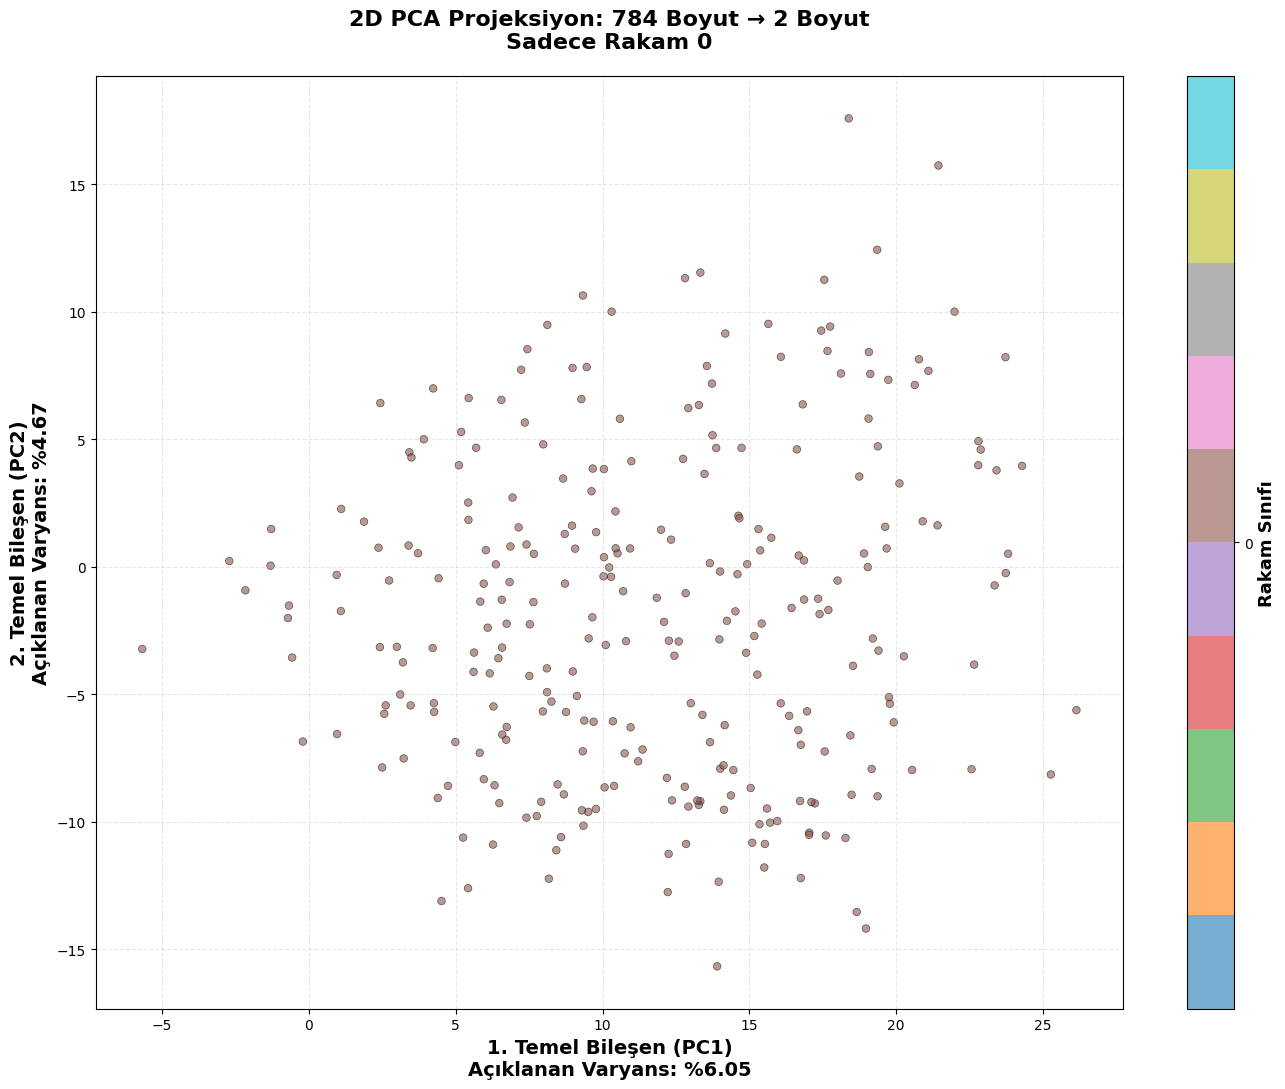


📊 2D PROJEKSİYON İSTATİSTİKLERİ:
  • Toplam açıklanan varyans: %10.73
  • Gösterilen nokta sayısı: 285
  • PC1 katkısı: %6.05
  • PC2 katkısı: %4.67

💡 2 bileşenle %10.7 bilgi korundu!


In [10]:
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

@interact(
    digit_filter=Dropdown(options=['Tümü'] + list(range(10)), value='Tümü',
                         description='Rakam:'),
    point_size=IntSlider(min=10, max=100, value=30, step=10,
                        description='Nokta Boyutu:'),
    alpha=FloatSlider(min=0.1, max=1.0, value=0.6, step=0.1,
                     description='Saydamlık:')
)
def interactive_2d_projection(digit_filter, point_size, alpha):
    """İnteraktif 2D PCA Projeksiyon"""

    # 2D PCA
    pca_2d = PCA(n_components=2)
    X_2d = pca_2d.fit_transform(X_scaled)

    # Filtreleme
    if digit_filter == 'Tümü':
        mask = np.ones(len(y), dtype=bool)
        title_suffix = "Tüm Rakamlar"
    else:
        mask = y == digit_filter
        title_suffix = f"Sadece Rakam {digit_filter}"

    # Görselleştirme
    fig, ax = plt.subplots(figsize=(14, 11))

    scatter = ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                        c=y[mask], cmap='tab10',
                        s=point_size, alpha=alpha,
                        edgecolors='black', linewidth=0.5)

    ax.set_xlabel(f'1. Temel Bileşen (PC1)\nAçıklanan Varyans: %{pca_2d.explained_variance_ratio_[0]*100:.2f}',
                  fontsize=14, fontweight='bold')
    ax.set_ylabel(f'2. Temel Bileşen (PC2)\nAçıklanan Varyans: %{pca_2d.explained_variance_ratio_[1]*100:.2f}',
                  fontsize=14, fontweight='bold')
    ax.set_title(f'2D PCA Projeksiyon: 784 Boyut → 2 Boyut\n{title_suffix}',
                 fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
    cbar.set_label('Rakam Sınıfı', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # İstatistikler
    total_variance = np.sum(pca_2d.explained_variance_ratio_) * 100
    n_points = mask.sum()

    print(f"\n{'='*60}")
    print(f"📊 2D PROJEKSİYON İSTATİSTİKLERİ:")
    print(f"{'='*60}")
    print(f"  • Toplam açıklanan varyans: %{total_variance:.2f}")
    print(f"  • Gösterilen nokta sayısı: {n_points:,}")
    print(f"  • PC1 katkısı: %{pca_2d.explained_variance_ratio_[0]*100:.2f}")
    print(f"  • PC2 katkısı: %{pca_2d.explained_variance_ratio_[1]*100:.2f}")
    print(f"\n💡 2 bileşenle %{total_variance:.1f} bilgi korundu!")
    print(f"{'='*60}")

### 8.2 - 3D Projeksiyon

In [20]:
@interact(
    elevation=IntSlider(min=0, max=90, value=30, step=5,
                       description='Yükselme:'),
    azimuth=IntSlider(min=0, max=360, value=45, step=15,
                     description='Azimut:'),
    digit_filter=Dropdown(options=['Tümü'] + list(range(10)), value='Tümü',
                         description='Rakam:')
)
def interactive_3d_projection(elevation, azimuth, digit_filter):
    """İnteraktif 3D PCA Projeksiyon"""

    # 3D PCA
    pca_3d = PCA(n_components=3)
    X_3d = pca_3d.fit_transform(X_scaled)

    # Filtreleme
    if digit_filter == 'Tümü':
        mask = np.ones(len(y), dtype=bool)
        title_suffix = "Tüm Rakamlar"
    else:
        mask = y == digit_filter
        title_suffix = f"Sadece Rakam {digit_filter}"

    # 3D Görselleştirme
    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                        c=y[mask], cmap='tab10',
                        s=30, alpha=0.6,
                        edgecolors='black', linewidth=0.3)

    ax.set_xlabel(f'PC1 (%{pca_3d.explained_variance_ratio_[0]*100:.2f})',
                  fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PC2 (%{pca_3d.explained_variance_ratio_[1]*100:.2f})',
                  fontsize=12, fontweight='bold')
    ax.set_zlabel(f'PC3 (%{pca_3d.explained_variance_ratio_[2]*100:.2f})',
                  fontsize=12, fontweight='bold')
    ax.set_title(f'3D PCA Projeksiyon: 784 Boyut → 3 Boyut\n{title_suffix}',
                 fontsize=16, fontweight='bold', pad=20)

    # Kamera açısı
    ax.view_init(elev=elevation, azim=azimuth)

    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
    cbar.set_label('Rakam Sınıfı', fontsize=12, fontweight='bold')

    # Grid
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # İstatistikler
    total_variance = np.sum(pca_3d.explained_variance_ratio_) * 100
    n_points = mask.sum()

    print(f"\n{'='*60}")
    print(f"📊 3D PROJEKSİYON İSTATİSTİKLERİ:")
    print(f"{'='*60}")
    print(f"  • Toplam açıklanan varyans: %{total_variance:.2f}")
    print(f"  • Gösterilen nokta sayısı: {n_points:,}")
    print(f"  • PC1 katkısı: %{pca_3d.explained_variance_ratio_[0]*100:.2f}")
    print(f"  • PC2 katkısı: %{pca_3d.explained_variance_ratio_[1]*100:.2f}")
    print(f"  • PC3 katkısı: %{pca_3d.explained_variance_ratio_[2]*100:.2f}")
    print(f"  • Kamera: Yükselme={elevation}°, Azimut={azimuth}°")
    print(f"\n💡 3 bileşenle %{total_variance:.1f} bilgi korundu!")
    print(f"{'='*60}")

interactive(children=(IntSlider(value=30, description='Yükselme:', max=90, step=5), IntSlider(value=45, descri…

## 9️⃣ 📋 Sonuçlar ve Özet

### PCA Analizi Tamamlandı! 🎉

### 🎓 PCA'yı Ne Zaman Kullanmalıyız?

#### ✅ PCA Kullanılacak Durumlar:
1. **Çok fazla özellik var** (yüzlerce/binlerce)
2. **Görselleştirme gerekiyor** (2D/3D'ye indirgemek için)
3. **Model yavaş çalışıyor** (boyut azaltarak hızlandırma)
4. **Özellikler birbirine benziyor** (korelasyon yüksek)
5. **Overfitting var** (model ezberlemiş)

#### ❌ PCA Kullanılmayacak Durumlar:
1. **Zaten az özellik var** (<10-20)
2. **Özelliklerin yorumlanabilirliği önemli** (PCA bileşenler soyut)
3. **Non-lineer ilişkiler** (PCA sadece lineer)
4. **Sınıf bilgisi önemli** (LDA daha iyi olabilir)

#### 🔄 Alternatifler:
- **t-SNE:** Non-lineer, görselleştirme için
- **UMAP:** t-SNE gibi ama daha hızlı
- **LDA:** Sınıflandırma için
- **Autoencoders:** Derin öğrenme ile

---

In [12]:
# Özet istatistikler
print("="*80)
print("🎓 PCA ANALİZİ ÖZET RAPORU")
print("="*80)
print("\n📊 VERİ SETİ:")
print(f"  • Kaynak: MNIST El Yazısı Rakamlar")
print(f"  • Örnek sayısı: {X.shape[0]:,}")
print(f"  • Orijinal boyut: {X.shape[1]} (28×28 piksel)")
print(f"  • Sınıf sayısı: 10 (0-9 rakamlar)")

print("\n🎯 PCA SONUÇLARI:")
print(f"  • %90 varyans için: {n_components_90} bileşen")
print(f"  • %95 varyans için: {n_components_95} bileşen")
print(f"  • %99 varyans için: {n_components_99} bileşen")

print("\n📉 BOYUT İNDİRGEME:")
print(f"  • Orijinal → %95 varyans: 784 → {n_components_95} boyut")
print(f"  • Boyut azaltma oranı: %{(1-n_components_95/784)*100:.1f}")
print(f"  • Sıkıştırma oranı: {784/n_components_95:.2f}x")

print("\n💡 İLK 5 BILEŞEN:")
for i in range(5):
    print(f"  PC{i+1}: %{explained_variance[i]*100:.2f} "
          f"(Kümülatif: %{cumulative_variance[i]*100:.2f})")

print("\n✅ PCA'NIN AVANTAJLARI:")
print("  1. Boyut azaltma → Daha hızlı hesaplama")
print("  2. Gürültü filtreleme → Daha temiz veri")
print("  3. Görselleştirme → 2D/3D projeksiyon")
print("  4. Özellik çıkarımı → Daha iyi model performansı")
print("  5. Veri sıkıştırma → Daha az depolama")

print("\n🎯 UYGULAMA ALANLARI:")
print("  • Görüntü sıkıştırma ve işleme")
print("  • Yüz tanıma (Eigenfaces)")
print("  • Anomali tespiti")
print("  • Veri görselleştirme")
print("  • Makine öğrenmesi ön işleme")
print("  • Genetik veri analizi")

print("\n" + "="*80)
print("✨ İnteraktif PCA analizi tamamlandı!")
print("="*80)

🎓 PCA ANALİZİ ÖZET RAPORU

📊 VERİ SETİ:
  • Kaynak: MNIST El Yazısı Rakamlar
  • Örnek sayısı: 3,000
  • Orijinal boyut: 784 (28×28 piksel)
  • Sınıf sayısı: 10 (0-9 rakamlar)

🎯 PCA SONUÇLARI:
  • %90 varyans için: 171 bileşen
  • %95 varyans için: 247 bileşen
  • %99 varyans için: 437 bileşen

📉 BOYUT İNDİRGEME:
  • Orijinal → %95 varyans: 784 → 247 boyut
  • Boyut azaltma oranı: %68.5
  • Sıkıştırma oranı: 3.17x

💡 İLK 5 BILEŞEN:
  PC1: %6.05 (Kümülatif: %6.05)
  PC2: %4.67 (Kümülatif: %10.73)
  PC3: %4.24 (Kümülatif: %14.96)
  PC4: %3.29 (Kümülatif: %18.26)
  PC5: %2.89 (Kümülatif: %21.15)

✅ PCA'NIN AVANTAJLARI:
  1. Boyut azaltma → Daha hızlı hesaplama
  2. Gürültü filtreleme → Daha temiz veri
  3. Görselleştirme → 2D/3D projeksiyon
  4. Özellik çıkarımı → Daha iyi model performansı
  5. Veri sıkıştırma → Daha az depolama

🎯 UYGULAMA ALANLARI:
  • Görüntü sıkıştırma ve işleme
  • Yüz tanıma (Eigenfaces)
  • Anomali tespiti
  • Veri görselleştirme
  • Makine öğrenmesi ön işleme
  

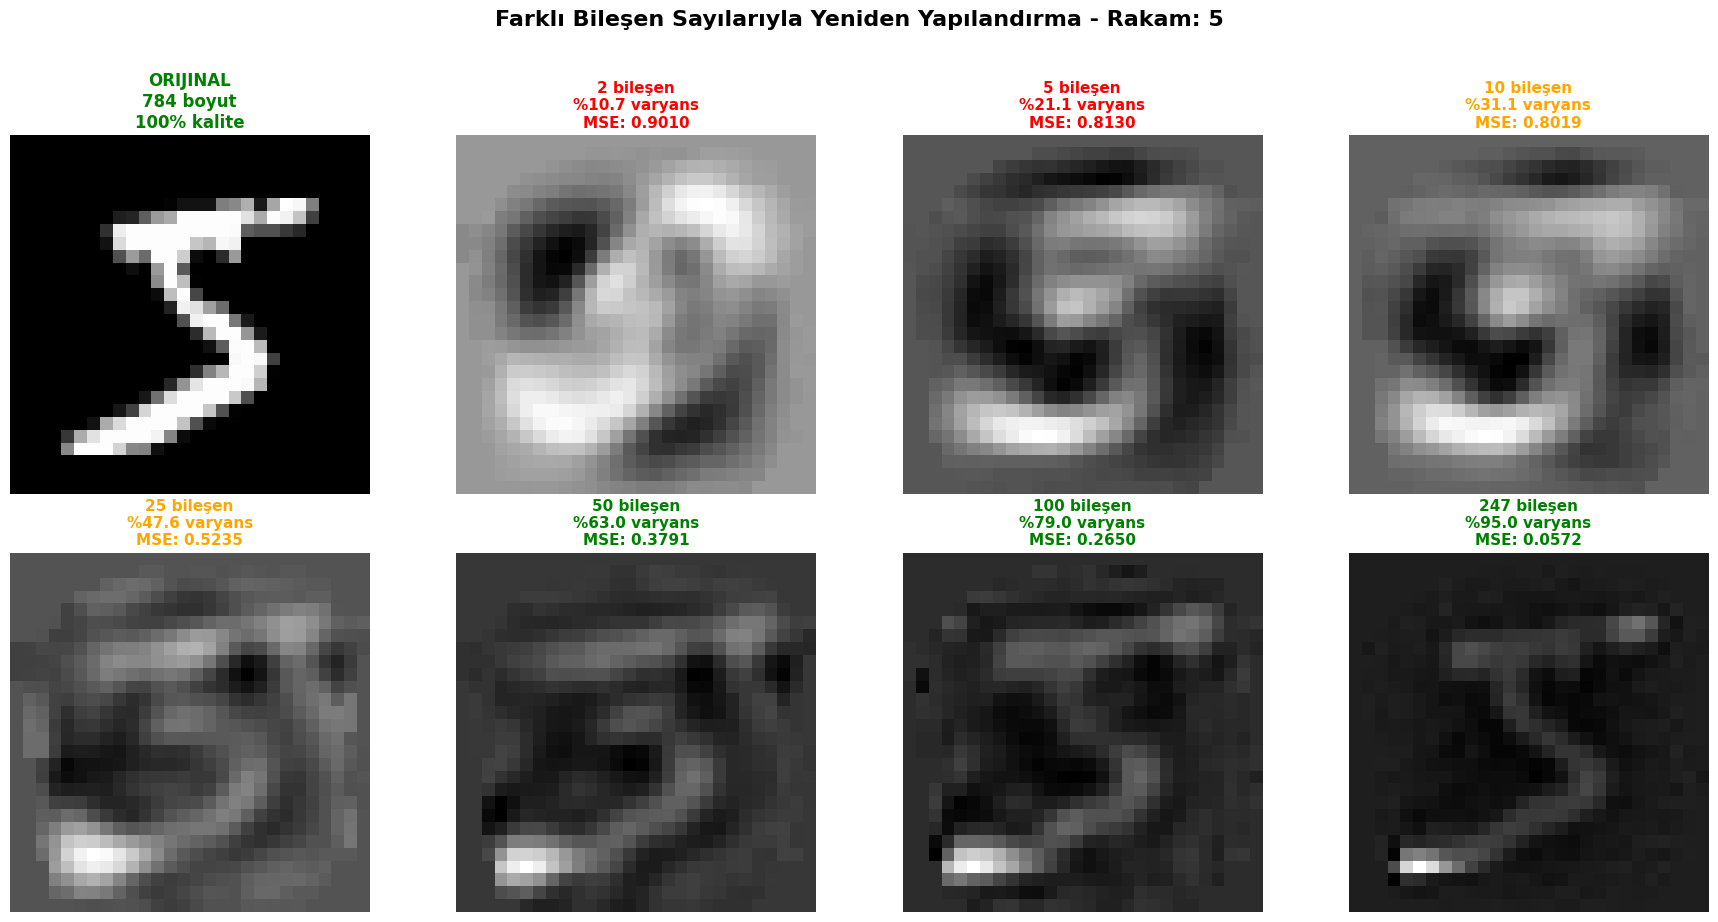


💡 GÖZLEM:
  • 2 bileşen: Rakam zar zor seçilebilir
  • 10 bileşen: Rakam anlaşılıyor ama bulanık
  • 50 bileşen: Oldukça iyi kalite
  • 247 bileşen (%95 varyans): Neredeyse orijinal gibi!


In [18]:
# 🎨 Görsel Karşılaştırma: Farklı Boyutlarda Yeniden Yapılandırma

import matplotlib.pyplot as plt

# Farklı bileşen sayılarıyla karşılaştırma
component_counts = [2, 5, 10, 25, 50, 100, n_components_95]
sample_idx = 0  # İlk örnek

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f'Farklı Bileşen Sayılarıyla Yeniden Yapılandırma - Rakam: {y[sample_idx]}',
             fontsize=16, fontweight='bold', y=1.02)

# Orijinal görüntü
ax = axes[0, 0]
ax.imshow(X[sample_idx].reshape(28, 28), cmap='gray')
ax.set_title(f'ORIJINAL\n784 boyut\n100% kalite', fontsize=12, fontweight='bold', color='green')
ax.axis('off')

# Farklı bileşen sayılarıyla
for idx, n_comp in enumerate(component_counts):
    ax = axes[(idx+1)//4, (idx+1)%4]

    # PCA uygula
    pca_temp = PCA(n_components=n_comp)
    X_reduced = pca_temp.fit_transform(X_scaled)
    X_recon = pca_temp.inverse_transform(X_reduced)

    # Görselleştir
    ax.imshow(X_recon[sample_idx].reshape(28, 28), cmap='gray')

    variance = np.sum(pca_temp.explained_variance_ratio_) * 100
    mse = np.mean((X_scaled[sample_idx] - X_recon[sample_idx])**2)

    # Renk kodlaması
    color = 'red' if n_comp < 10 else 'orange' if n_comp < 50 else 'green'

    ax.set_title(f'{n_comp} bileşen\n%{variance:.1f} varyans\nMSE: {mse:.4f}',
                fontsize=11, fontweight='bold', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 GÖZLEM:")
print("="*70)
print("  • 2 bileşen: Rakam zar zor seçilebilir")
print("  • 10 bileşen: Rakam anlaşılıyor ama bulanık")
print("  • 50 bileşen: Oldukça iyi kalite")
print(f"  • {n_components_95} bileşen (%95 varyans): Neredeyse orijinal gibi!")
print("="*70)

---

## 🎓 Matematiksel Formülasyon

### PCA Adımları:

1. **Veri Merkezleme:**
   $$\tilde{X} = X - \mu$$

2. **Kovaryans Matrisi:**
   $$\Sigma = \frac{1}{n}\tilde{X}^T\tilde{X}$$

3. **Eigendecomposition:**
   $$\Sigma v = \lambda v$$
   - $v$: Eigenvector (Temel bileşen)
   - $\lambda$: Eigenvalue (Açıklanan varyans)

4. **Projeksiyon:**
   $$Z = \tilde{X}W$$
   - $W$: İlk $k$ eigenvector
   - $Z$: İndirgenmiş veri

5. **Yeniden Yapılandırma:**
   $$\hat{X} = ZW^T + \mu$$

### Açıklanan Varyans Oranı:
$$\text{Explained Variance Ratio} = \frac{\lambda_i}{\sum_j \lambda_j}$$

---

## 📚 Kaynaklar

1. **Pearson, K. (1901)** - "On lines and planes of closest fit to systems of points in space"
2. **Hotelling, H. (1933)** - "Analysis of a complex of statistical variables into principal components"
3. **Turk & Pentland (1991)** - "Eigenfaces for Recognition"
4. **Scikit-learn Documentation** - https://scikit-learn.org/stable/modules/decomposition.html

---

## 💻 Interaktif Özellikler

Bu notebook'ta kullanılan interaktif widget'lar:

- ✅ **Scree Plot**: Bileşen sayısı ve varyans hedefi ayarlama
- ✅ **Eigenfaces**: Farklı temel bileşenleri keşfetme
- ✅ **Yeniden Yapılandırma**: Görüntü kalitesini karşılaştırma
- ✅ **2D Projeksiyon**: Sınıf ayrımını görselleştirme
- ✅ **3D Projeksiyon**: Farklı açılardan veriyi inceleme

---

## 🚀 Sonraki Adımlar

1. **Kernel PCA**: Lineer olmayan veri için
2. **Incremental PCA**: Büyük veri setleri için
3. **Sparse PCA**: Yorumlanabilir bileşenler için
4. **t-SNE/UMAP**: Alternatif boyut indirgeme teknikleri
5. **Autoencoders**: Derin öğrenme ile boyut indirgeme

---

### ⭐ Demo Tamamlandı!

Bu interaktif notebook'u kullanarak PCA'nın nasıl çalıştığını detaylı şekilde gösterdiniz.

**Sunumda gösterebileceğiniz ana noktalar:**
1. ✅ Gerçek veri kullanımı (MNIST)
2. ✅ Kovaryans matrisi analizi
3. ✅ Temel bileşenlerin görselleştirilmesi
4. ✅ İnteraktif boyut indirgeme
5. ✅ 2D/3D projeksiyon ile sınıf ayrımı
6. ✅ %70 boyut azaltma ile %95 bilgi koruma

## 🤔 Sık Sorulan Sorular (SSS)

### 1. PCA veri kaybeder mi?
**Evet ama kontrollü bir kayıp.** Önemsiz bilgileri (gürültü) atıyoruz. %95 varyans = verinin %95'ini koruyoruz.

### 2. Kaç bileşen seçmeliyim?
**3 yöntem:**
- Scree plot'ta "dirsek noktası"
- %90-95 kümülatif varyans hedefi
- Cross-validation ile en iyi performansı veren sayı

### 3. PCA her zaman işe yarar mı?
**Hayır.** PCA sadece lineer ilişkiler için çalışır. Non-lineer veriler için Kernel PCA veya t-SNE kullanın.

### 4. Standardizasyon şart mı?
**Özellikler farklı ölçeklerdeyse evet.** Aksi halde büyük değerli özellikler PCA'yı domine eder.

### 5. PCA supervised mı unsupervised mı?
**Unsupervised.** Sınıf etiketlerine (label) bakmadan çalışır. Sadece veri dağılımına bakar.

### 6. PCA overfitting'i önler mi?
**Evet, bir dereceye kadar.** Boyut azaltarak modelin karmaşıklığını düşürür.

### 7. PCA sonrası model performansı artar mı?
**Değişir.** Bazen artar (gürültü azalması), bazen azalır (bilgi kaybı). Test etmek gerek!

---

---

## 🎁 BONUS: Toplu Karşılaştırma Tablosu

Farklı bileşen sayılarının karşılaştırmalı analizi

🔄 Karşılaştırma tablosu oluşturuluyor...

📊 KARŞILAŞTIRMALI ANALİZ TABLOSU
 Bileşen Varyans (%)      MSE Boyut Azaltma (%) Sıkıştırma
       2       10.73 0.740162              99.7    392.00x
       5       21.15 0.653757              99.4    156.80x
      10       31.12 0.571037              98.7     78.40x
      25       47.61 0.434371              96.8     31.36x
      50       63.03 0.306523              93.6     15.68x
     100       79.01 0.174017              87.2      7.84x
     150       87.59 0.102874              80.9      5.23x
     247       94.98 0.041607              68.5      3.17x
     300       96.77 0.026780              61.7      2.61x
     500       99.48 0.004325              36.2      1.57x

💡 ÖNERİLER:
  • Hızlı prototipleme: 50 bileşen (%63.0 varyans)
  • Dengeli seçim: 247 bileşen (%95 varyans) ⭐ ÖNERILEN
  • Yüksek kalite: 300 bileşen (%96.8 varyans)


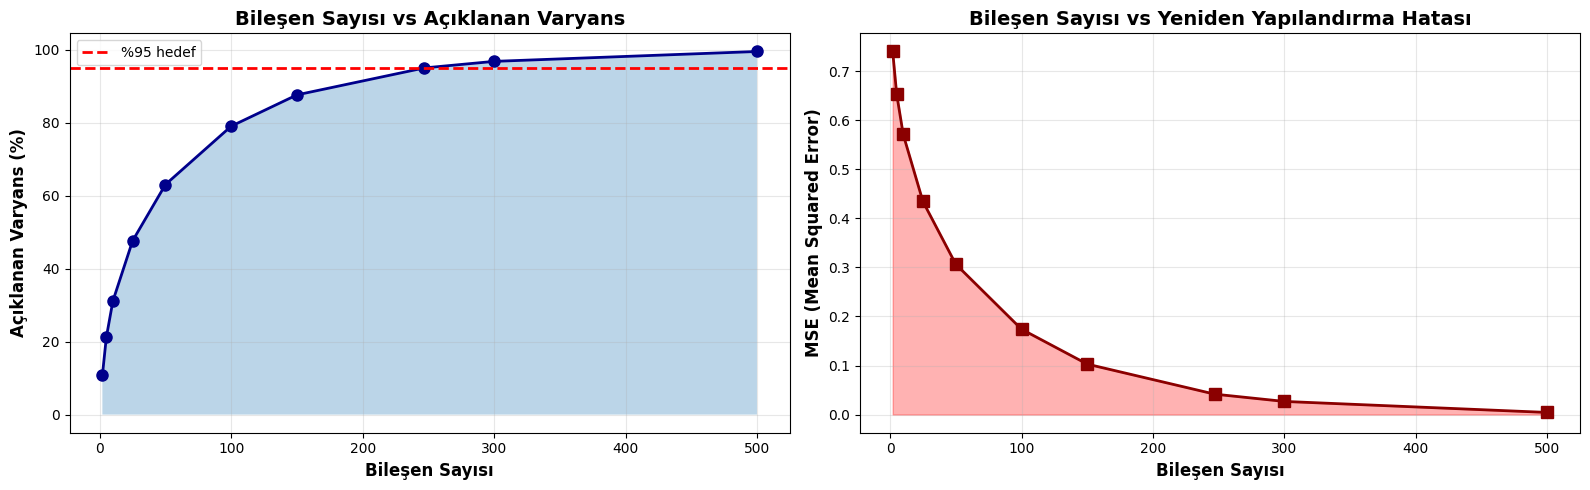


✅ Karşılaştırmalı analiz tamamlandı!


In [19]:
# Karşılaştırmalı analiz tablosu
components_list = [2, 5, 10, 25, 50, 100, 150, n_components_95, 300, 500]
results = []

print("🔄 Karşılaştırma tablosu oluşturuluyor...\n")

for n_comp in components_list:
    if n_comp <= len(explained_variance):
        # PCA uygula
        pca_temp = PCA(n_components=n_comp)
        X_reduced = pca_temp.fit_transform(X_scaled)
        X_recon = pca_temp.inverse_transform(X_reduced)

        # Metrikler
        variance = np.sum(pca_temp.explained_variance_ratio_) * 100
        mse = np.mean((X_scaled - X_recon)**2)
        compression_ratio = 784 / n_comp
        dimension_reduction = (1 - n_comp/784) * 100

        results.append({
            'Bileşen': n_comp,
            'Varyans (%)': f'{variance:.2f}',
            'MSE': f'{mse:.6f}',
            'Boyut Azaltma (%)': f'{dimension_reduction:.1f}',
            'Sıkıştırma': f'{compression_ratio:.2f}x'
        })

# Tablo oluştur
import pandas as pd
df = pd.DataFrame(results)

print("="*80)
print("📊 KARŞILAŞTIRMALI ANALİZ TABLOSU")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# En iyi seçim önerisi
print("\n💡 ÖNERİLER:")
print(f"  • Hızlı prototipleme: 50 bileşen (%{np.sum(PCA(50).fit(X_scaled).explained_variance_ratio_)*100:.1f} varyans)")
print(f"  • Dengeli seçim: {n_components_95} bileşen (%95 varyans) ⭐ ÖNERILEN")
print(f"  • Yüksek kalite: 300 bileşen (%{np.sum(PCA(300).fit(X_scaled).explained_variance_ratio_)*100:.1f} varyans)")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: Varyans vs Bileşen
comp_nums = [r['Bileşen'] for r in results]
variances = [float(r['Varyans (%)']) for r in results]
axes[0].plot(comp_nums, variances, marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0].axhline(y=95, color='red', linestyle='--', linewidth=2, label='%95 hedef')
axes[0].fill_between(comp_nums, variances, alpha=0.3)
axes[0].set_xlabel('Bileşen Sayısı', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Açıklanan Varyans (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Bileşen Sayısı vs Açıklanan Varyans', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Sağ: MSE vs Bileşen
mses = [float(r['MSE']) for r in results]
axes[1].plot(comp_nums, mses, marker='s', linewidth=2, markersize=8, color='darkred')
axes[1].fill_between(comp_nums, mses, alpha=0.3, color='red')
axes[1].set_xlabel('Bileşen Sayısı', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MSE (Mean Squared Error)', fontsize=12, fontweight='bold')
axes[1].set_title('Bileşen Sayısı vs Yeniden Yapılandırma Hatası', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Karşılaştırmalı analiz tamamlandı!")

---

## 📖 Hızlı Referans Rehberi

### 🔧 Temel PCA Kodu (Scikit-learn)

```python
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Veriyi standartlaştır
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA uygula (%95 varyans hedefi)
pca = PCA(n_components=0.95)  # veya sabit sayı: n_components=50
X_reduced = pca.fit_transform(X_scaled)

# 3. Kaç bileşen seçildi?
print(f"Seçilen bileşen sayısı: {pca.n_components_}")

# 4. Geri dönüştür
X_reconstructed = pca.inverse_transform(X_reduced)
```

### 📊 Önemli Metrikler

```python
# Açıklanan varyans oranları
explained_variance = pca.explained_variance_ratio_

# Kümülatif varyans
cumulative_variance = np.cumsum(explained_variance)

# Her bileşenin önemini göster
for i, var in enumerate(explained_variance[:5]):
    print(f"PC{i+1}: %{var*100:.2f}")
```

### 🎨 Görselleştirme Şablonları

```python
# 2D Projeksiyon
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.show()

# Scree Plot
plt.bar(range(1, 21), explained_variance[:20])
plt.xlabel('Temel Bileşen')
plt.ylabel('Açıklanan Varyans')
plt.show()
```

---

## 🎓 Öğrenme Kaynakları

### 📹 Video Kaynaklar
- **StatQuest (Josh Starmer):** PCA açıklamaları (YouTube)
- **3Blue1Brown:** Lineer cebir görselleştirmeleri

### 📚 Kitaplar
- **"Hands-On Machine Learning" (Aurélien Géron)** - Bölüm 8
- **"Pattern Recognition and Machine Learning" (Bishop)** - Bölüm 12

### 🔗 Online Kaynaklar
- Scikit-learn PCA Documentation
- Towards Data Science (Medium)
- Machine Learning Mastery

---

## ✨ İLERİ SEVİYE KONULAR

Daha fazla öğrenmek isteyenler için:

### 1️⃣ **Kernel PCA**
- Non-lineer veri için
- RBF, polynomial kernel'lar
```python
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=2, kernel='rbf')
```

### 2️⃣ **Incremental PCA**
- Büyük veri setleri için
- Batch processing
```python
from sklearn.decomposition import IncrementalPCA
ipca = IncrementalPCA(n_components=50, batch_size=100)
```

### 3️⃣ **Sparse PCA**
- Yorumlanabilir bileşenler
- Özellik seçimi ile birlikte
```python
from sklearn.decomposition import SparsePCA
spca = SparsePCA(n_components=50, alpha=0.1)
```

### 4️⃣ **PCA + Machine Learning**
```python
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# PCA ve model birlikte
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('classifier', LogisticRegression())
])

pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)
```

---

## 🎯 SONUÇ

Bu notebook'ta öğrendikleriniz:

✅ **Kavramlar:** Varyans, kovaryans, temel bileşen  
✅ **Uygulama:** MNIST üzerinde 784 → 150 boyut  
✅ **Görselleştirme:** 2D/3D projeksiyon  
✅ **İnteraktif:** Farklı parametre denemeleri  

### 🚀 Sonraki Adımlarınız:

1. **Kendi verinizle deneyin:** Başka bir veri seti yükleyin
2. **Parametrelerle oynayın:** Farklı bileşen sayıları test edin
3. **Model entegrasyonu:** PCA + Classifier birleştirin
4. **t-SNE karşılaştırması:** PCA vs t-SNE farkını görün

### 📩 Geri Bildirim

Bu notebook'u geliştirmek için önerilerinizi paylaşın!

---

**🎉 TEBRİKLER! PCA'yı başarıyla öğrendiniz!**

*Son güncelleme: 2025 - İnteraktif PCA Eğitim Notebook'u*